In [1]:
import torch
from torch import nn
from dataset import Rice2
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam

from utility import plot_images, plot_samples, denorm, plot_losses
from losses import vae_loss
from models import Autoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
model = Autoencoder(latent_dim=256).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",        # wir wollen den Loss minimieren
    factor=0.5,        # lr wird halbiert wenn Plateau
    patience=2,        # ... nach 5 Epochen ohne Verbesserung
    threshold=0.1
)

num_epochs = 1
batch_size = 8
beta = 0.1
train_losses, val_losses = [], []
train_recon, val_recon = [], []
train_kl, val_kl = [], []

#data_dir = "/home/christopher/sync/projekte/GNN_projekt/RICE_DATASET/RICE2"
data_dir ="/data/home/lec42675/cloud_removal/RICE_DATASET/RICE2"
dataset = Rice2(data_dir)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
training_data, val_data = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)


train_dataloader = DataLoader(training_data, batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size, shuffle=True)

Epoch [1/1], Train: nan, Val: nan, LR: 1.00e-03


/usr/lib/python3/dist-packages/matplotlib/cm.py:440: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


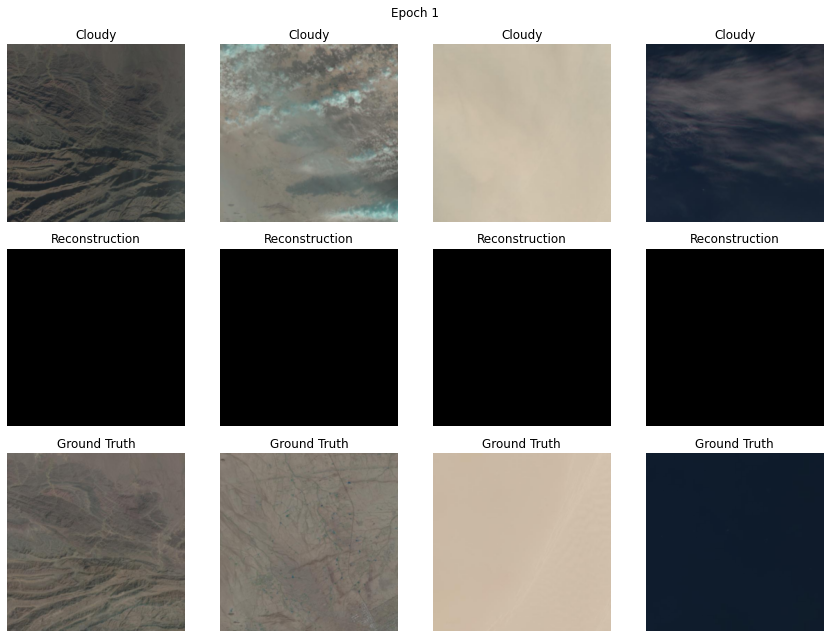

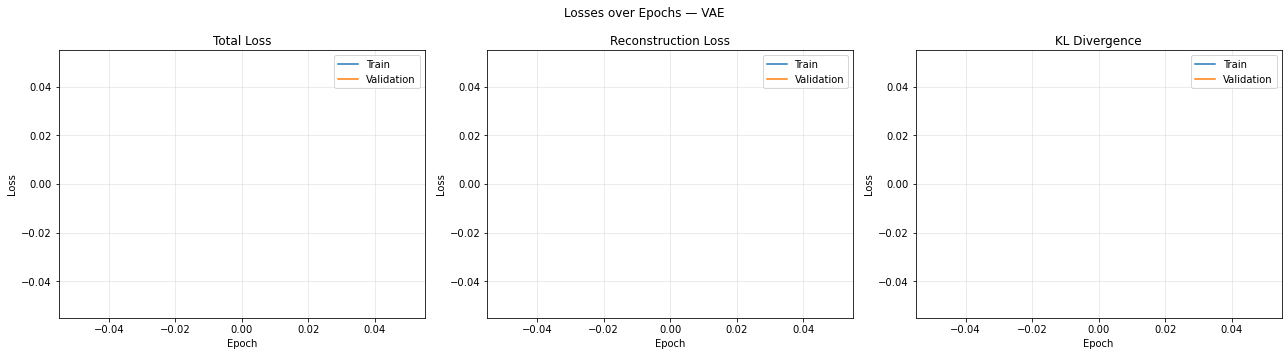

In [3]:
for epoch in range(num_epochs):
    model.train()
    total_loss = total_recon = total_kl = 0
    for cloudy, label, mask in train_dataloader:
        cloudy, label = cloudy.to(device), label.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(cloudy, label)
        loss, recon_loss, kl_loss = vae_loss(recon, label, mu, logvar, beta)
        loss.backward()
        optimizer.step()
        total_loss  += loss.item()
        total_recon += recon_loss.item()
        total_kl    += kl_loss.item()
    train_losses.append(total_loss / len(train_dataloader))
    train_recon.append(total_recon / len(train_dataloader))
    train_kl.append(total_kl / len(train_dataloader))

    model.eval()
    total_loss = total_recon = total_kl = 0
    with torch.no_grad():
        for cloudy, label, mask in val_dataloader:
            cloudy, label = cloudy.to(device), label.to(device)
            recon, mu, logvar = model(cloudy, label)
            loss, recon_loss, kl_loss = vae_loss(recon, label, mu, logvar, beta)
            total_loss  += loss.item()
            total_recon += recon_loss.item()
            total_kl    += kl_loss.item()
    val_losses.append(total_loss / len(val_dataloader))
    val_recon.append(total_recon / len(val_dataloader))
    val_kl.append(total_kl / len(val_dataloader))

    scheduler.step(val_losses[-1])
    
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch [{epoch+1}/{num_epochs}], Train: {train_losses[-1]:.4f}, "
          f"Val: {val_losses[-1]:.4f}, LR: {current_lr:.2e}")
    plot_samples(model, val_dataloader, device, epoch)
    plot_losses(train_losses, val_losses, train_recon, val_recon, train_kl, val_kl, model_name="VAE")